# 17 — ORB Feature Detection and Matching

**Section:** Perception · **Mirrors MATLAB:** *Feature Detection, Extraction, and Matching*

ORB (Oriented FAST and Rotated BRIEF) is a fast, rotation-invariant feature detector + descriptor. We detect features in two synthetic images (one is a rotated + translated version of the other) and match them with Hamming distance + cross-check.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

H, W = 240, 320
img1 = np.zeros((H, W), dtype=np.uint8)
cv2.rectangle(img1, (50, 50), (100, 100), 200, -1)
cv2.circle(img1, (200, 80), 30, 150, -1)
cv2.line(img1, (60, 150), (260, 200), 250, 3)
cv2.putText(img1, 'PYROBOT', (30, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.0, 255, 2)
img1 = cv2.GaussianBlur(img1, (3, 3), 0)

M = cv2.getRotationMatrix2D((W / 2, H / 2), 20, 1.0)
M[0, 2] += 25
M[1, 2] += 10
img2 = cv2.warpAffine(img1, M, (W, H))


In [2]:
orb = cv2.ORB_create(nfeatures=300)
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = sorted(bf.match(des1, des2), key=lambda m: m.distance)[:40]
print(f"img1 features: {len(kp1)}  img2 features: {len(kp2)}  matches kept: {len(matches)}")

out = cv2.drawMatches(img1, kp1, img2, kp2, matches, None,
                       flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)


img1 features: 214  img2 features: 145  matches kept: 40


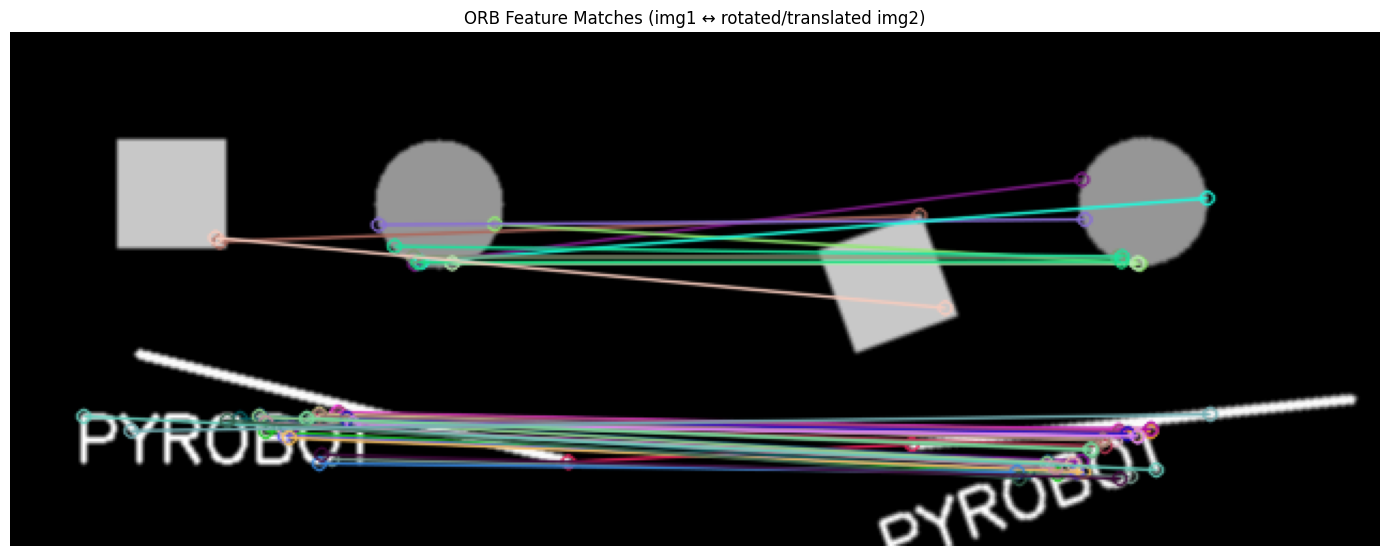

In [3]:
plt.figure(figsize=(14, 6))
plt.imshow(out, cmap='gray')
plt.title('ORB Feature Matches (img1 ↔ rotated/translated img2)')
plt.axis('off')
plt.tight_layout()
plt.show()
